In [3]:
import pandas as pd
df = pd.read_csv('listings_cleaned.csv')
df.head()

,Unnamed: 0,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,...,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,Rental_stratergy,host_business_type,is_high_availability
0,0,2384,Hyde Park - Walk to University of Chicago,2613,Rebecca,Hyde Park,41.787900,-87.587800,Private room,119.0,...,257,2025-08-07,1.97,1,348,10,R17000015609,Standard,Single,1
1,1,7126,Tiny Studio Apartment 94 Walk Score,17928,Sarah,West Town,41.901660,-87.680210,Entire home/apt,89.0,...,595,2025-09-01,3.01,1,302,47,R24000114046,Short-Term,Single,1
2,2,10945,The Biddle House (#1),33004,At Home Inn,Lincoln Park,41.911960,-87.639810,Entire home/apt,203.0,...,129,2025-09-06,0.93,6,325,24,2209984,Standard,large scale business,1
3,3,12140,Lincoln Park Guest House,46734,Shar And Robert,Lincoln Park,41.923570,-87.649470,Private room,339.0,...,19,2025-09-07,0.15,1,156,3,2398451,Short-Term,Single,0
4,4,28749,Quirky Bucktown Loft w/ Parking No Parties,27506,Lauri,Logan Square,41.920226,-87.679613,Entire home/apt,258.0,...,265,2025-09-01,1.47,1,74,37,R24000113825,Short-Term,Single,0


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

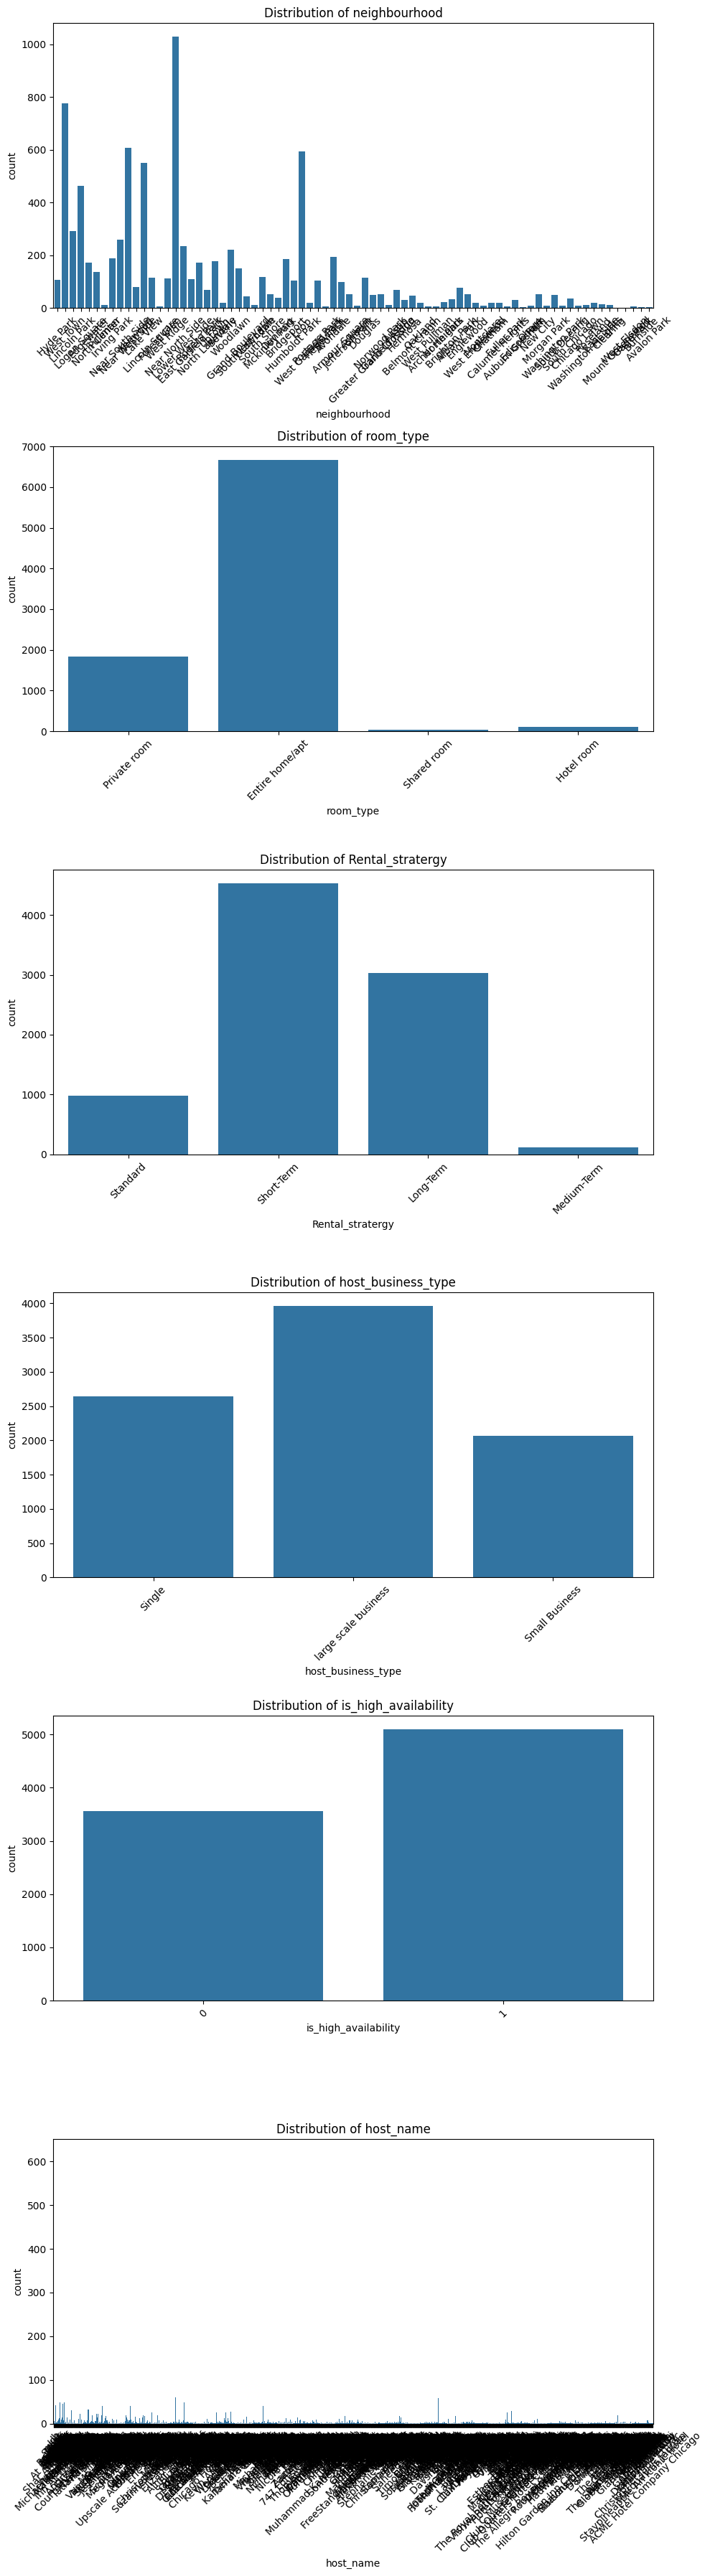

In [13]:
categorical_cols = ['neighbourhood', 'room_type', 'Rental_stratergy', 'host_business_type', 'is_high_availability','host_name']

# Determine the number of subplots needed
num_cols = len(categorical_cols)

# Create subplots with adjusted figsize
fig, axes = plt.subplots(num_cols, 1, figsize=(10, 6 * num_cols)) # Increased height per subplot

# Iterate through categorical columns and create a bar plot for each
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45) # Rotate labels for better readability

plt.tight_layout()
plt.show()

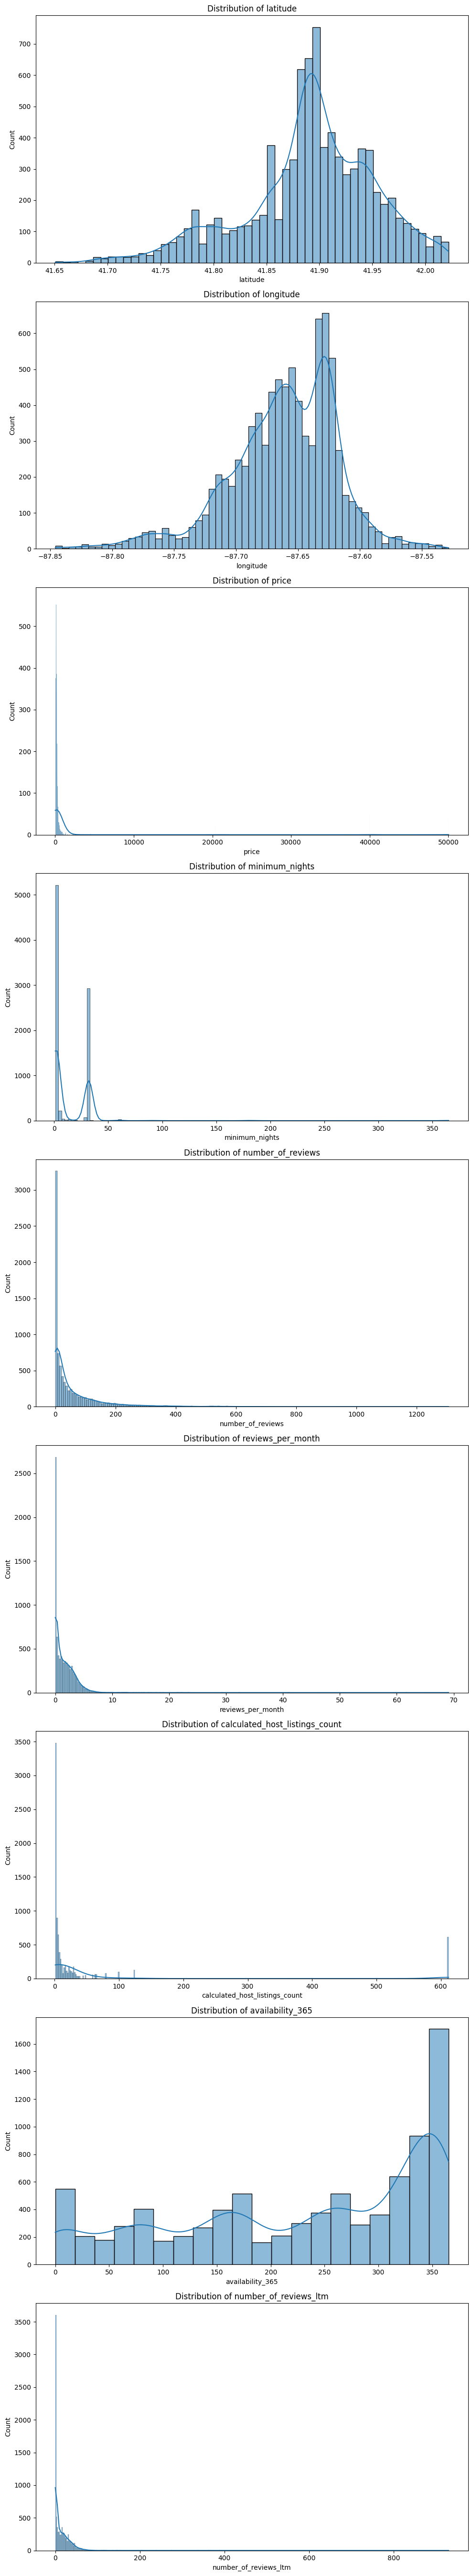

In [10]:
continuous_cols = ['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm']

# Determine the number of subplots needed
num_cols_cont = len(continuous_cols)

# Create subplots with adjusted figsize
fig_cont, axes_cont = plt.subplots(num_cols_cont, 1, figsize=(10, 6 * num_cols_cont))

# Iterate through continuous columns and create a histogram for each
for i, col in enumerate(continuous_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes_cont[i])
    axes_cont[i].set_title(f'Distribution of {col}')
    axes_cont[i].set_xlabel(col)
    axes_cont[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

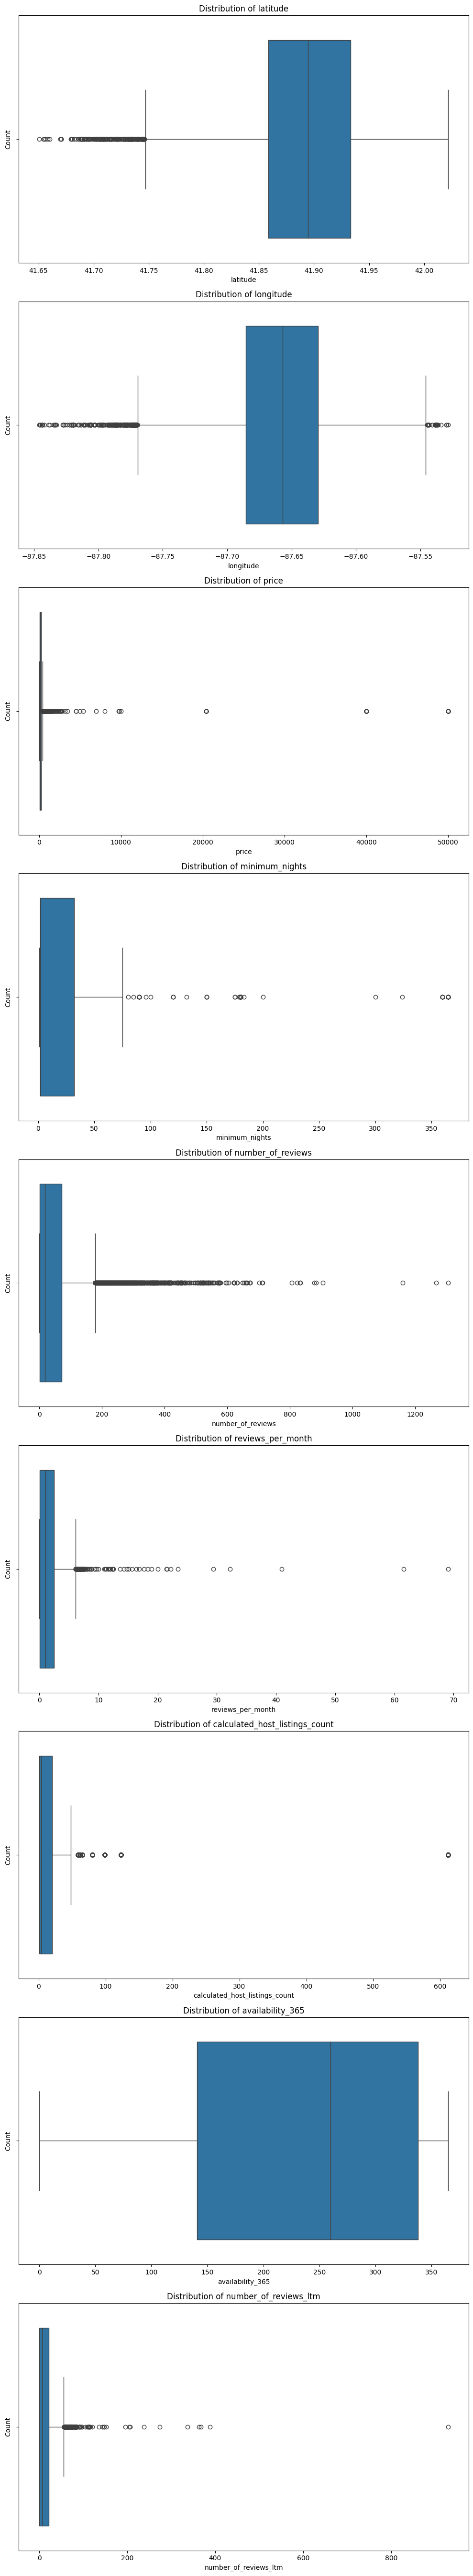

In [11]:
continuous_cols = ['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm']

# Determine the number of subplots needed
num_cols_cont = len(continuous_cols)

# Create subplots with adjusted figsize
fig_cont, axes_cont = plt.subplots(num_cols_cont, 1, figsize=(10, 6 * num_cols_cont))

# Iterate through continuous columns and create a histogram for each
for i, col in enumerate(continuous_cols):
    sns.boxplot(data=df, x=col, ax=axes_cont[i])
    axes_cont[i].set_title(f'Distribution of {col}')
    axes_cont[i].set_xlabel(col)
    axes_cont[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [14]:
for col in categorical_cols:
    print(f"Column: {col}")
    print(df[col].value_counts())
    print("\n")

Column: neighbourhood
neighbourhood
Near North Side    1028
West Town           777
Near West Side      607
Loop                593
Lake View           549
                   ... 
Avalon Park           5
Edison Park           3
Burnside              3
Mount Greenwood       2
West Elsdon           2
Name: count, Length: 76, dtype: int64


Column: room_type
room_type
Entire home/apt    6670
Private room       1840
Hotel room          114
Shared room          35
Name: count, dtype: int64


Column: Rental_stratergy
Rental_stratergy
Short-Term     4535
Long-Term      3027
Standard        986
Medium-Term     111
Name: count, dtype: int64


Column: host_business_type
host_business_type
large scale business    3959
Single                  2638
Small Business          2062
Name: count, dtype: int64


Column: is_high_availability
is_high_availability
1    5100
0    3559
Name: count, dtype: int64


Column: host_name
host_name
Unknown Host         621
LuxurybookingsFZE    123
Cloud9               

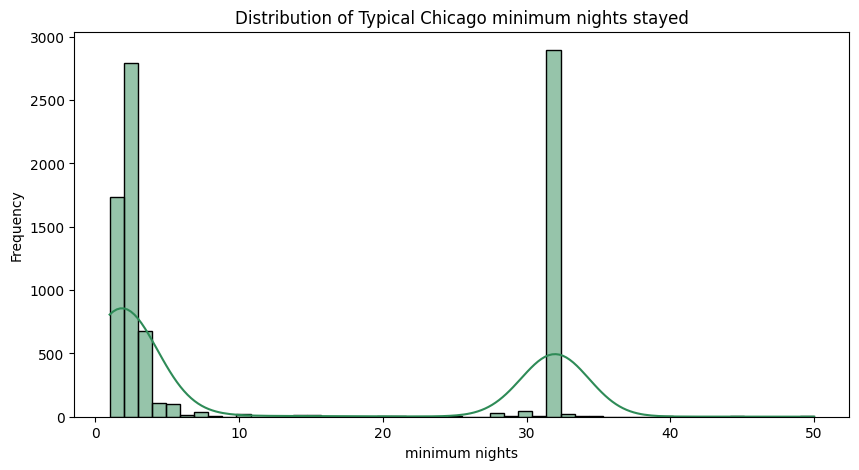

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter to only look at properties below $1,000 a night
typical_nights = df[df['minimum_nights'] <= 50]

plt.figure(figsize=(10, 5))

# Adjust bins to make the distribution look smooth and continuous
sns.histplot(data=typical_nights, x='minimum_nights', bins=50, kde=True, color='seagreen')

plt.xlabel('minimum nights')
plt.ylabel('Frequency')
plt.title('Distribution of Typical Chicago minimum nights stayed')

plt.show()

In [24]:
df['number_of_reviews'].median()

18.0

### Descriptive Statistics for Numerical Variables

In [26]:
display(df.describe())

,Unnamed: 0,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,is_high_availability
count,8659.000000,8.659000e+03,8.659000e+03,8659.000000,8659.000000,8659.000000,8659.000000,8659.000000,8659.000000,8659.000000,8659.000000,8659.000000,8659.000000
mean,4332.020788,7.479047e+17,2.308395e+08,41.890632,-87.661371,700.511260,14.197020,56.851715,1.573631,55.097471,229.897910,13.820880,0.588983
std,2500.056638,5.616535e+17,2.076688e+08,0.062112,0.043751,4521.943499,24.026762,96.202346,2.103475,155.084132,117.261337,21.720843,0.492047
min,0.000000,2.384000e+03,2.613000e+03,41.650640,-87.845893,13.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2167.500000,4.873859e+07,4.693943e+07,41.858753,-87.685605,96.000000,2.000000,1.000000,0.100000,1.000000,141.000000,0.000000,0.000000
50%,4332.000000,8.883028e+17,1.469237e+08,41.894760,-87.656780,152.000000,2.000000,18.000000,1.020000,4.000000,260.000000,6.000000,1.000000
75%,6496.500000,1.254172e+18,4.310192e+08,41.933485,-87.629640,233.000000,32.000000,72.000000,2.520000,20.000000,338.000000,22.000000,1.000000
max,8662.000000,1.514812e+18,7.185739e+08,42.021950,-87.528420,50032.000000,365.000000,1306.000000,69.100000,612.000000,365.000000,930.000000,1.000000


### Price Distribution by Neighbourhood

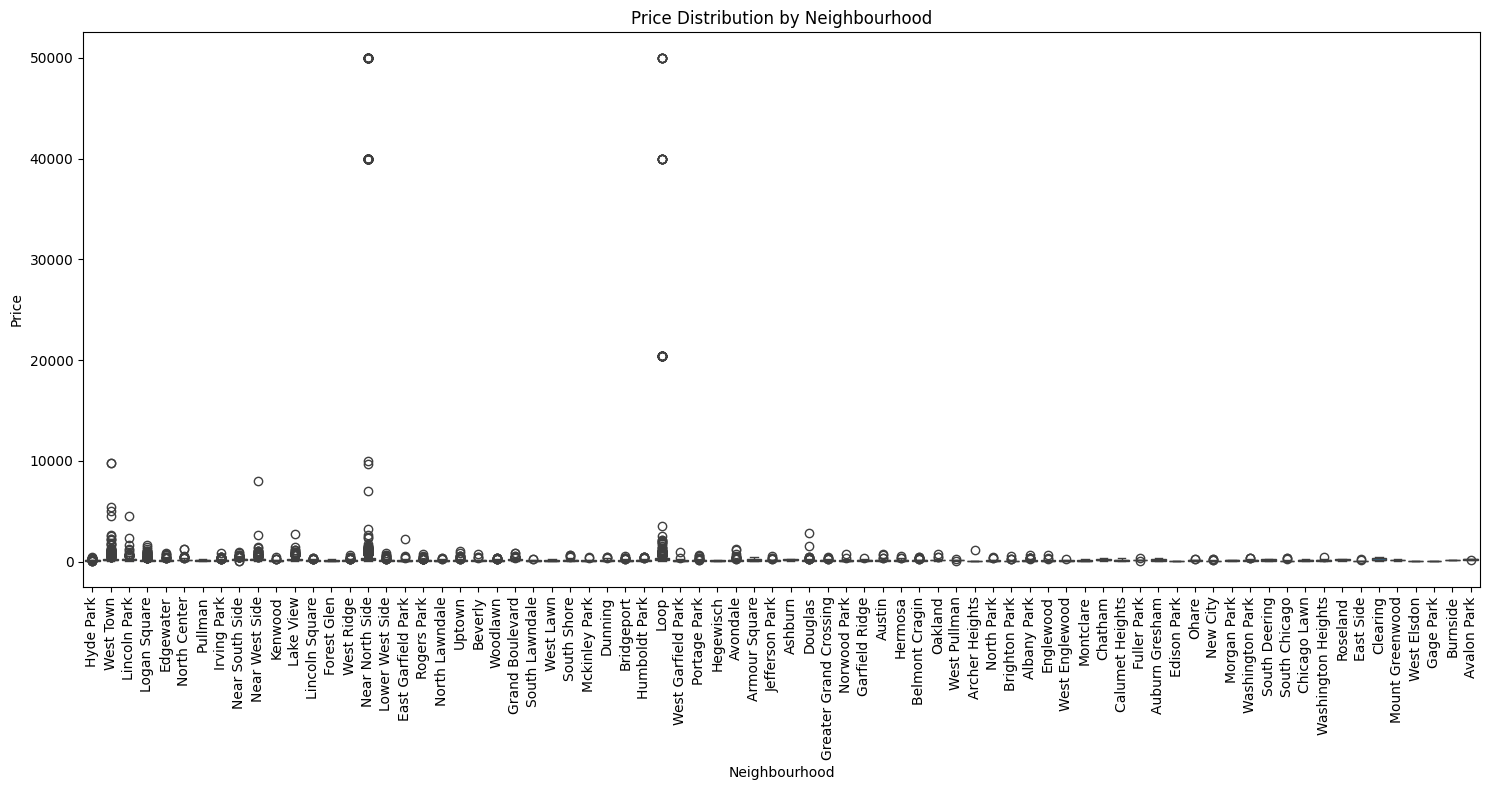

In [27]:
plt.figure(figsize=(15, 8))
sns.boxplot(x='neighbourhood', y='price', data=df)
plt.title('Price Distribution by Neighbourhood')
plt.xlabel('Neighbourhood')
plt.ylabel('Price')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Price Distribution by Room Type (Filtered < $1000)

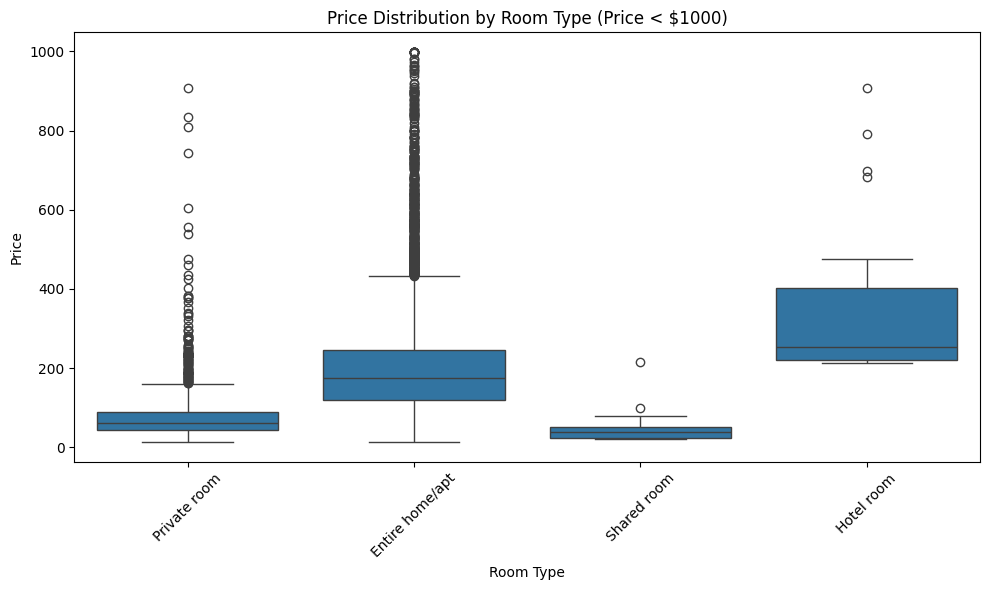

In [28]:
df_filtered = df[df['price'] < 1000]

plt.figure(figsize=(10, 6))
sns.boxplot(x='room_type', y='price', data=df_filtered)
plt.title('Price Distribution by Room Type (Price < $1000)')
plt.xlabel('Room Type')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Distribution of Listing Counts per Host

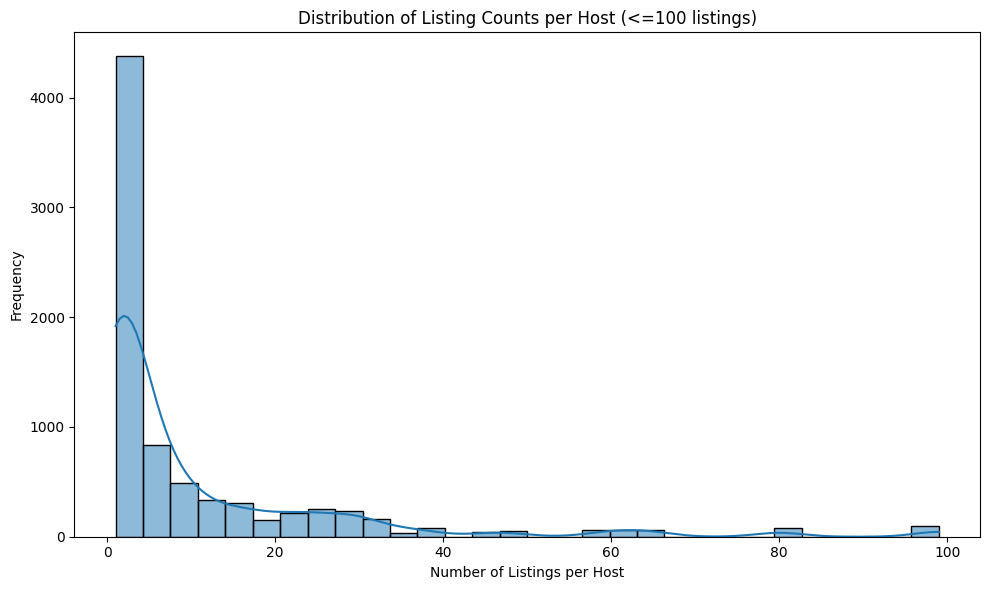

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(df[df['calculated_host_listings_count'] <= 100]['calculated_host_listings_count'], bins=30, kde=True)
plt.title('Distribution of Listing Counts per Host (<=100 listings)')
plt.xlabel('Number of Listings per Host')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Price Distribution by Property Type (Filtered < $1000)

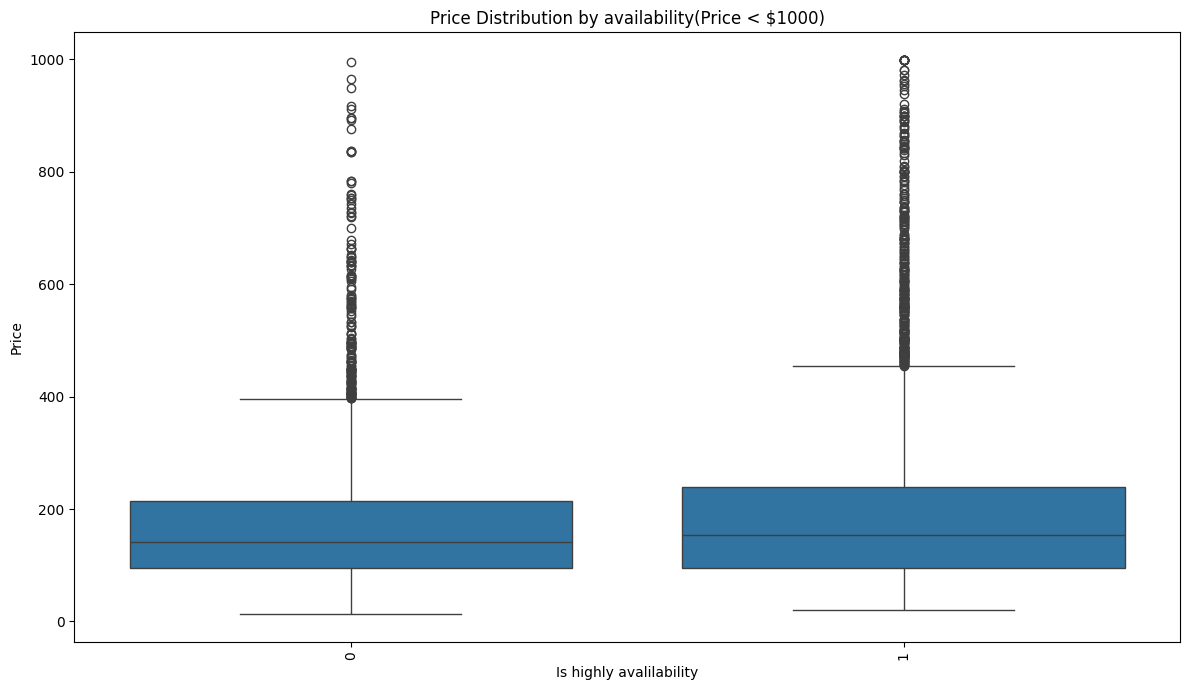

In [32]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='is_high_availability', y='price', data=df_filtered)
plt.title('Price Distribution by availability(Price < $1000)')
plt.xlabel('Is highly avalilability')
plt.ylabel('Price')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


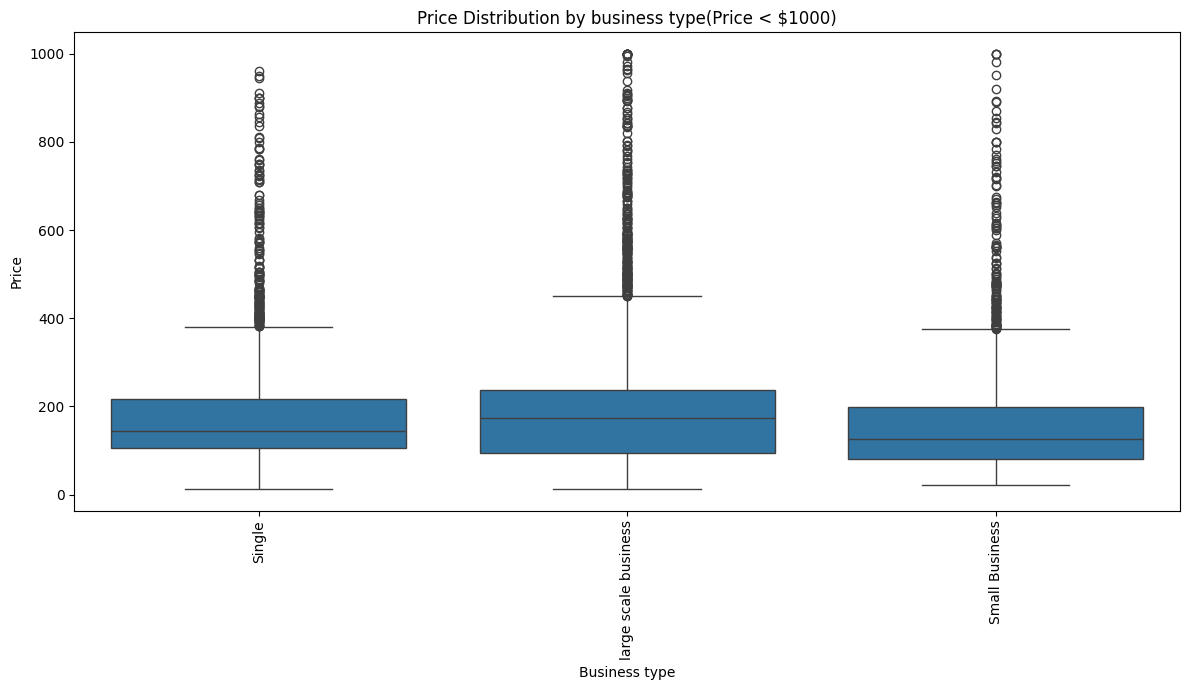

In [33]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='host_business_type', y='price', data=df_filtered)
plt.title('Price Distribution by business type(Price < $1000)')
plt.xlabel('Business')
plt.ylabel('Price')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


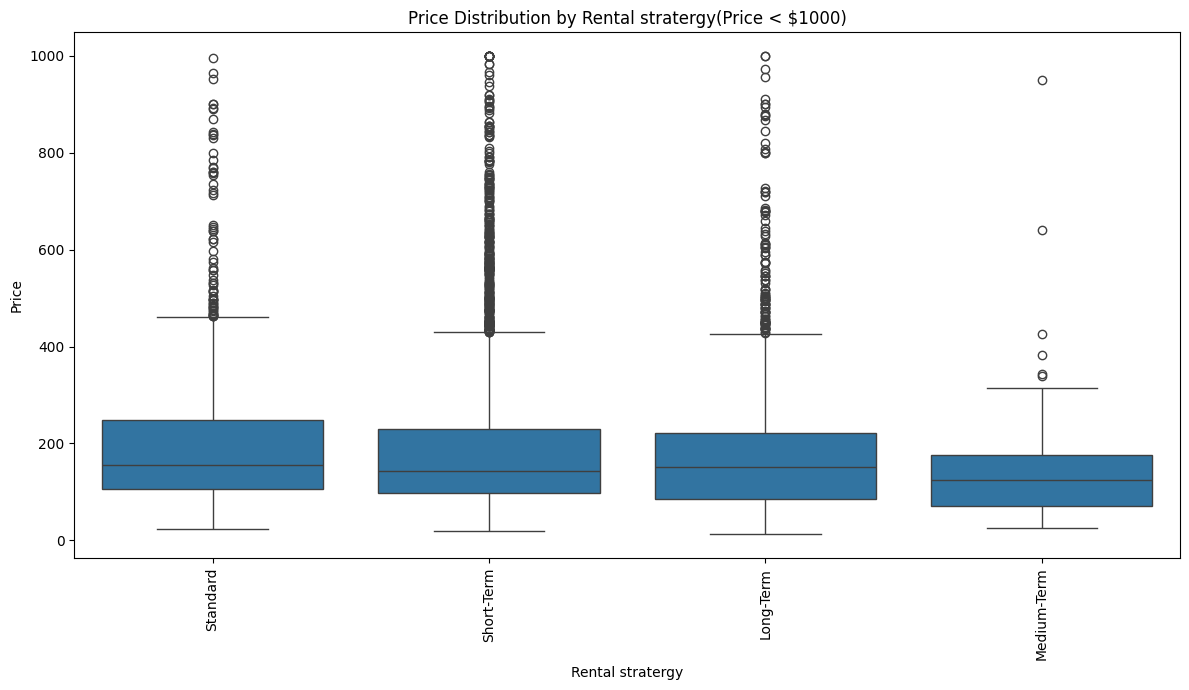

In [34]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Rental_stratergy', y='price', data=df_filtered)
plt.title('Price Distribution by Rental stratergy(Price < $1000)')
plt.xlabel('Rental stratergy')
plt.ylabel('Price')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Geographic Clustering by Room Type

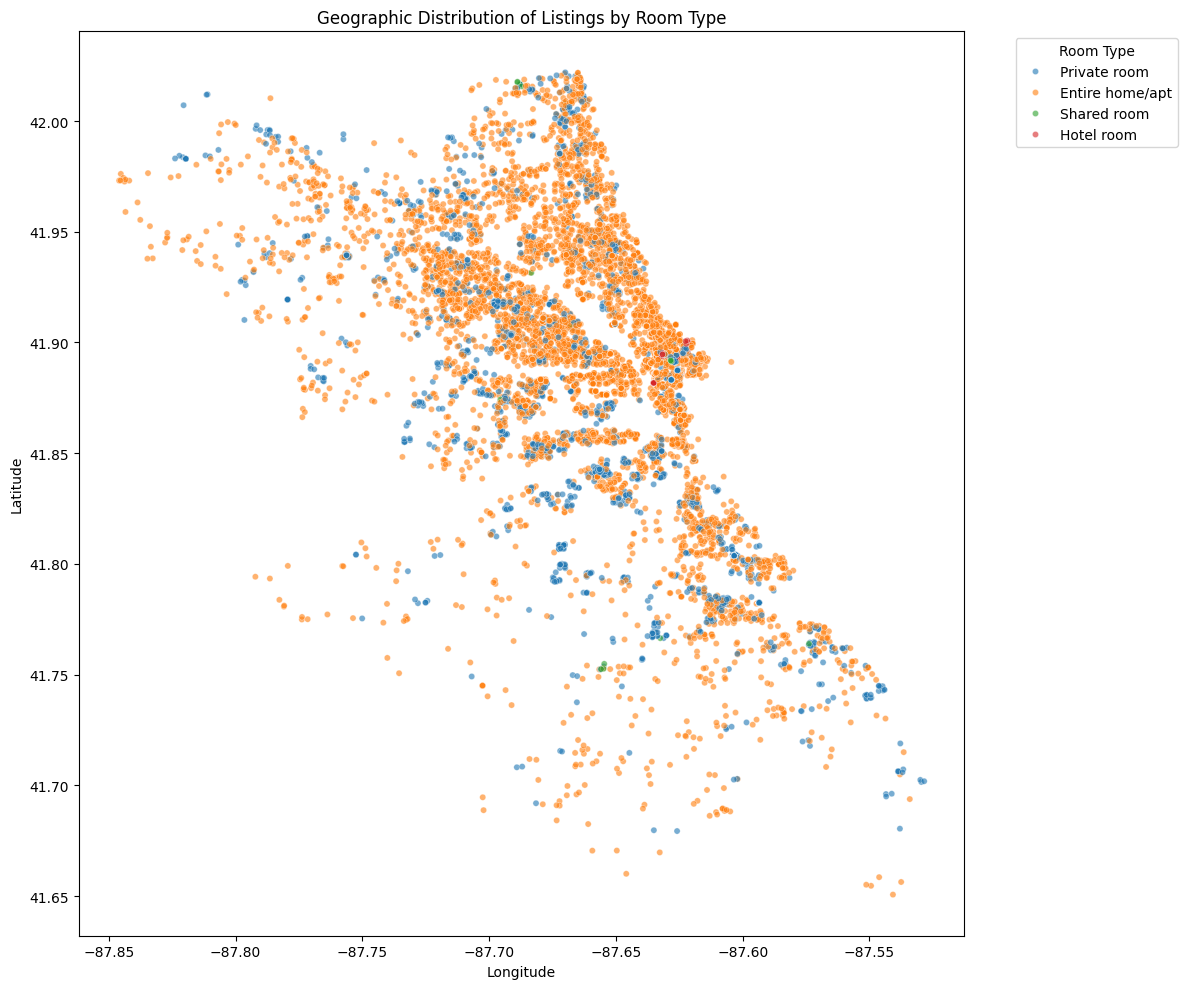

In [35]:
plt.figure(figsize=(12, 10))
sns.scatterplot(x='longitude', y='latitude', hue='room_type', data=df, s=20, alpha=0.6)
plt.title('Geographic Distribution of Listings by Room Type')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Room Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Geographic Clustering by Neighbourhood (Sampled for Clarity)

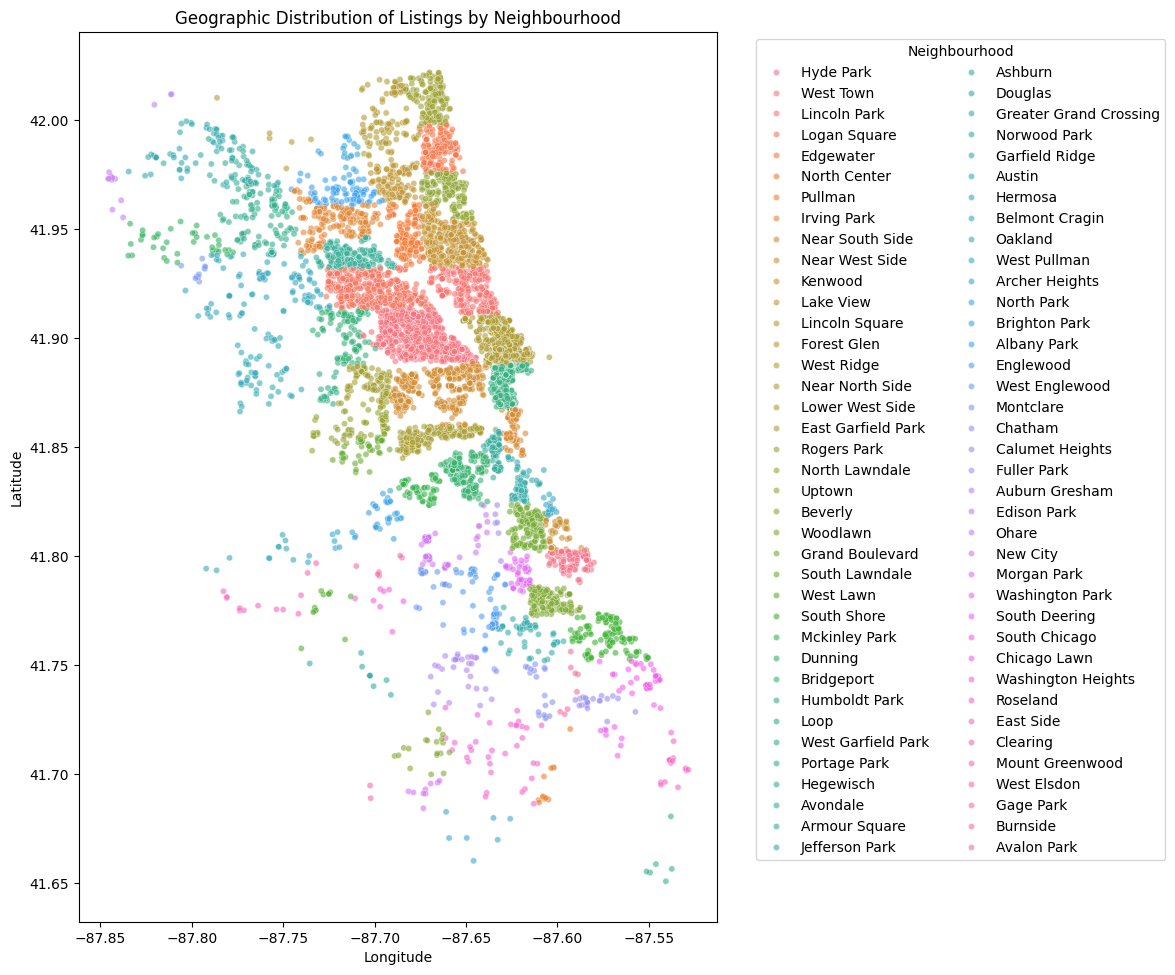

In [36]:
# Due to the large number of neighbourhoods, sampling might be necessary for a clear plot.
# Alternatively, we can plot the top N neighbourhoods or use a different visualization.
# For now, let's plot all, but be aware it might be dense.

plt.figure(figsize=(12, 10))
sns.scatterplot(x='longitude', y='latitude', hue='neighbourhood', data=df, s=20, alpha=0.6)
plt.title('Geographic Distribution of Listings by Neighbourhood')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Neighbourhood', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.tight_layout()
plt.show()

### Price Evolution Over the Calendar Year (based on Last Review Date)

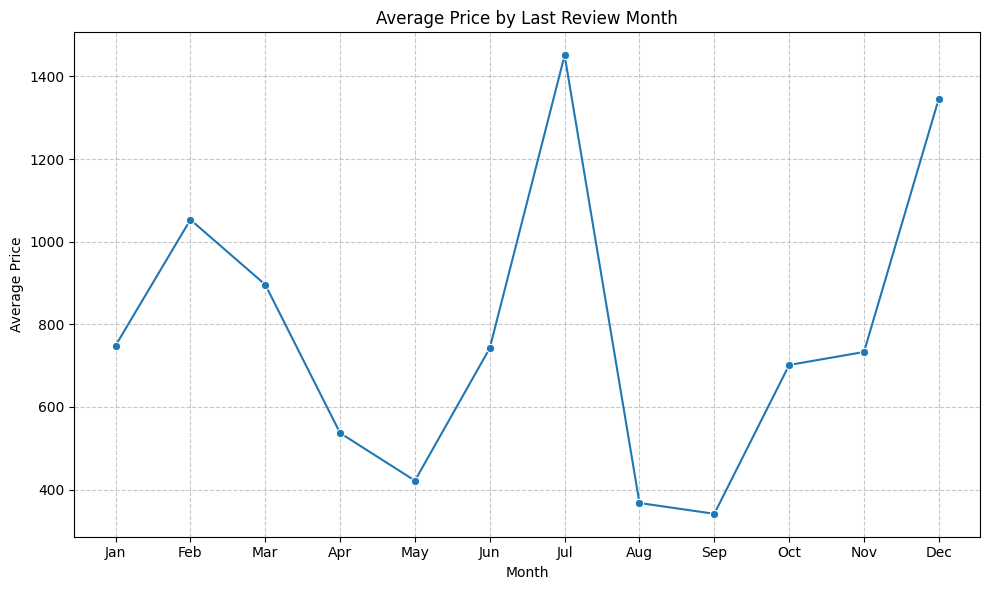

In [37]:
# Convert 'last_review' to datetime objects
df['last_review_date'] = pd.to_datetime(df['last_review'], errors='coerce')

# Extract the month from 'last_review_date'
df['review_month'] = df['last_review_date'].dt.month

# Calculate the average price per month
monthly_avg_price = df.groupby('review_month')['price'].mean().reset_index()

# Sort by month for proper plotting
monthly_avg_price = monthly_avg_price.sort_values('review_month')

# Plotting the price evolution
plt.figure(figsize=(10, 6))
sns.lineplot(x='review_month', y='price', data=monthly_avg_price, marker='o')
plt.title('Average Price by Last Review Month')
plt.xlabel('Month')
plt.ylabel('Average Price')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


This plot shows the average listing price grouped by the month of their last review. While this can give us an indication of pricing trends throughout the year (e.g., if listings reviewed in certain months tend to have higher prices), it's important to remember that `last_review` is a proxy and not a direct measure of a listing's price evolution over time. A more robust analysis would require a dataset with historical pricing information or listing creation dates.

### Correlation Heatmap for Numerical Variables

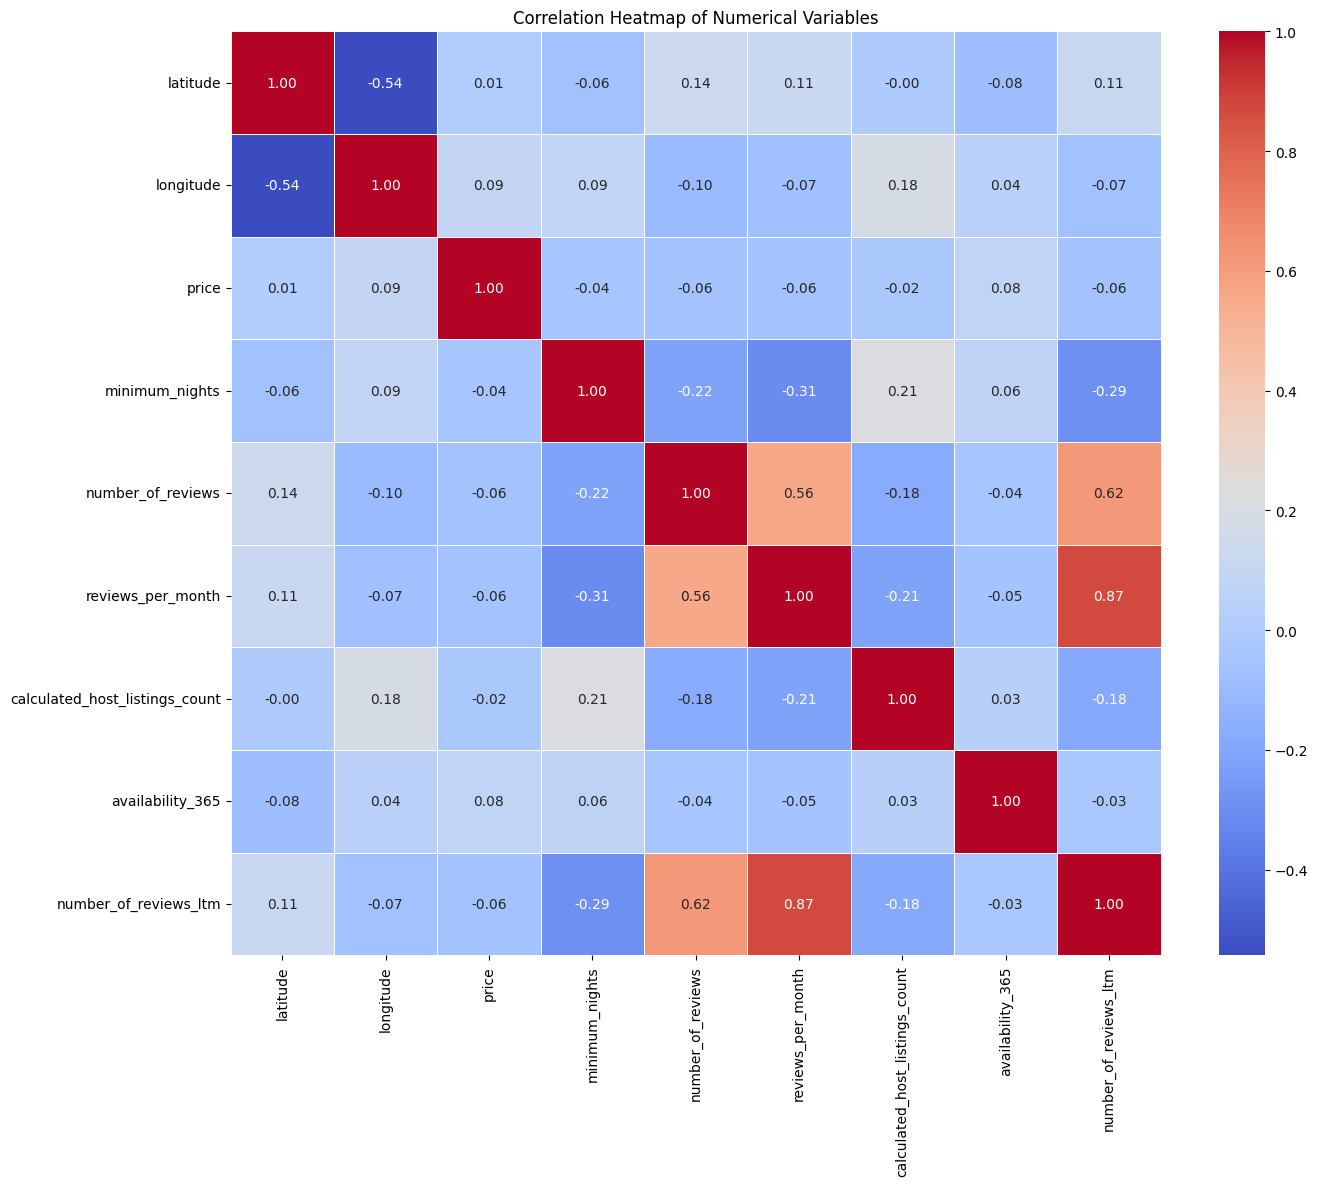

In [39]:
# Select only numerical columns for correlation calculation
numerical_cols = ['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm']

# Calculate the correlation matrix
corr_matrix = df[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

In [41]:
df['room_type'].value_counts()

,count
room_type,
Entire home/apt,6670
Private room,1840
Hotel room,114
Shared room,35


In [42]:
import scipy.stats as stats

# Isolate your groups (Example for H1: Entire Home vs Private Room)
group1 = df[df['room_type'] == 'Entire home/apt']['price']
group2 = df[df['room_type'] == 'Private room']['price']

# 1. Test for Normality (D'Agostino's K^2 Test handles large sample sizes well)
_, p_norm1 = stats.normaltest(group1)
_, p_norm2 = stats.normaltest(group2)

print(f"Normality p-values -> Group 1: {p_norm1}, Group 2: {p_norm2}")

# 2. Test for Homogeneity of Variances
_, p_levene = stats.levene(group1, group2)
print(f"Levene's Variance Test p-value: {p_levene}")

# 3. Automated Decision Logic
if p_norm1 > 0.05 and p_norm2 > 0.05 and p_levene > 0.05:
    print("Assumptions met: Use standard Student's t-test.")
elif p_levene <= 0.05 and (p_norm1 > 0.05 and p_norm2 > 0.05):
    print("Variances unequal, but normal: Use Welch's t-test (parametric).")
else:
    print("Assumptions violated (Non-normal): Use Mann-Whitney U test (non-parametric).")

Normality p-values -> Group 1: 0.0, Group 2: 0.0
Levene's Variance Test p-value: 2.1274780428794336e-20
Assumptions violated (Non-normal): Use Mann-Whitney U test (non-parametric).


### Mann-Whitney U Test for Price Comparison: Entire Home/Apt vs. Private Room

In [43]:
# Perform Mann-Whitney U Test
statistic, p_value = stats.mannwhitneyu(group1, group2, alternative='two-sided')

print(f"Mann-Whitney U Statistic: {statistic}")
print(f"Mann-Whitney U p-value: {p_value}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"Based on the Mann-Whitney U test (p-value = {p_value:.4f} < {alpha}), we reject the null hypothesis.")
    print("There is a statistically significant difference in price between 'Entire home/apt' and 'Private room' listings.")
    if group1.median() > group2.median():
        print("Specifically, 'Entire home/apt' tends to have higher prices than 'Private room'.")
    else:
        print("Specifically, 'Private room' tends to have higher prices than 'Entire home/apt'.")
else:
    print(f"Based on the Mann-Whitney U test (p-value = {p_value:.4f} >= {alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in price between 'Entire home/apt' and 'Private room' listings.")


Mann-Whitney U Statistic: 10695968.0
Mann-Whitney U p-value: 0.0
Based on the Mann-Whitney U test (p-value = 0.0000 < 0.05), we reject the null hypothesis.
There is a statistically significant difference in price between 'Entire home/apt' and 'Private room' listings.
Specifically, 'Entire home/apt' tends to have higher prices than 'Private room'.


### Hypothesis Test: Price Comparison for Listings with More vs. Fewer than 10 Reviews

In [44]:
import scipy.stats as stats

# Define groups based on number_of_reviews
group_more_than_10_reviews = df[df['number_of_reviews'] > 10]['price']
group_10_or_fewer_reviews = df[df['number_of_reviews'] <= 10]['price']

# 1. Test for Normality (D'Agostino's K^2 Test)
_, p_norm_more_than_10 = stats.normaltest(group_more_than_10_reviews)
_, p_norm_10_or_fewer = stats.normaltest(group_10_or_fewer_reviews)

print(f"Normality p-values -> Group (>10 reviews): {p_norm_more_than_10:.4f}, Group (<=10 reviews): {p_norm_10_or_fewer:.4f}")

# 2. Test for Homogeneity of Variances (Levene's Test)
_, p_levene_reviews = stats.levene(group_more_than_10_reviews, group_10_or_fewer_reviews)
print(f"Levene's Variance Test p-value: {p_levene_reviews:.4f}")

# Automated Decision Logic
alpha = 0.05
if p_norm_more_than_10 > alpha and p_norm_10_or_fewer > alpha and p_levene_reviews > alpha:
    print("Assumptions met: Use standard Student's t-test to compare means.")
elif p_levene_reviews <= alpha and (p_norm_more_than_10 > alpha and p_norm_10_or_fewer > alpha):
    print("Variances unequal, but normal: Use Welch's t-test to compare means.")
else:
    print("Assumptions violated (Non-normal): Use Mann-Whitney U test (non-parametric) to compare medians.")

Normality p-values -> Group (>10 reviews): 0.0000, Group (<=10 reviews): 0.0000
Levene's Variance Test p-value: 0.0000
Assumptions violated (Non-normal): Use Mann-Whitney U test (non-parametric) to compare medians.


### Mann-Whitney U Test for Price Comparison: More vs. Fewer than 10 Reviews

In [45]:
# Perform Mann-Whitney U Test
statistic, p_value = stats.mannwhitneyu(group_more_than_10_reviews, group_10_or_fewer_reviews, alternative='two-sided')

print(f"Mann-Whitney U Statistic: {statistic}")
print(f"Mann-Whitney U p-value: {p_value}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"Based on the Mann-Whitney U test (p-value = {p_value:.4f} < {alpha}), we reject the null hypothesis.")
    print("There is a statistically significant difference in price between listings with more than 10 reviews and those with 10 or fewer.")
    if group_more_than_10_reviews.median() > group_10_or_fewer_reviews.median():
        print("Specifically, listings with more than 10 reviews tend to have higher median prices.")
    else:
        print("Specifically, listings with 10 or fewer reviews tend to have higher median prices.")
else:
    print(f"Based on the Mann-Whitney U test (p-value = {p_value:.4f} >= {alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in price between listings with more than 10 reviews and those with 10 or fewer.")

Mann-Whitney U Statistic: 8563608.5
Mann-Whitney U p-value: 6.130705935926001e-08
Based on the Mann-Whitney U test (p-value = 0.0000 < 0.05), we reject the null hypothesis.
There is a statistically significant difference in price between listings with more than 10 reviews and those with 10 or fewer.
Specifically, listings with 10 or fewer reviews tend to have higher median prices.


### Hypothesis Test: Price Comparison Across Neighborhoods

In [46]:
import scipy.stats as stats

# Get all unique neighborhoods
neighbourhood_groups = [df['price'][df['neighbourhood'] == n] for n in df['neighbourhood'].unique() if len(df['price'][df['neighbourhood'] == n]) > 1]

# Due to the large number of groups, individual normality tests for each group are impractical and often lead to rejection for large sample sizes.
# Instead, we will generally rely on the robustness of ANOVA for larger sample sizes or use a non-parametric test if assumptions are severely violated.

# 1. Test for Homogeneity of Variances (Levene's Test)
# Levene's test is robust to non-normality.
_, p_levene_neighbourhood = stats.levene(*neighbourhood_groups)
print(f"Levene's Variance Test p-value: {p_levene_neighbourhood:.4f}")

# Automated Decision Logic
alpha = 0.05

if p_levene_neighbourhood > alpha: # Assuming approximate normality for large samples or relying on ANOVA robustness
    print("Variances appear homogeneous. Consider performing ANOVA (parametric).")
else:
    print("Variances are not homogeneous. It is recommended to use the Kruskal-Wallis H-test (non-parametric).")


Levene's Variance Test p-value: 0.0000
Variances are not homogeneous. It is recommended to use the Kruskal-Wallis H-test (non-parametric).


Given that the Levene's test indicates a violation of homogeneity of variances (p-value is very small), and price distributions are often not normal (as seen in previous EDA), the Kruskal-Wallis H-test is the more appropriate non-parametric test for comparing the medians of price across multiple independent groups (neighborhoods).

### Kruskal-Wallis H-test for Price Comparison Across Neighborhoods

In [47]:
# Perform Kruskal-Wallis H-test
statistic_kw, p_value_kw = stats.kruskal(*neighbourhood_groups)

print(f"Kruskal-Wallis H Statistic: {statistic_kw}")
print(f"Kruskal-Wallis H p-value: {p_value_kw:.4f}")

# Interpret the results
alpha = 0.05
if p_value_kw < alpha:
    print(f"Based on the Kruskal-Wallis H-test (p-value = {p_value_kw:.4f} < {alpha}), we reject the null hypothesis.")
    print("There is a statistically significant difference in price among at least some of the neighborhood groups.")
else:
    print(f"Based on the Kruskal-Wallis H-test (p-value = {p_value_kw:.4f} >= {alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in price among the neighborhood groups.")


Kruskal-Wallis H Statistic: 2621.4256203495634
Kruskal-Wallis H p-value: 0.0000
Based on the Kruskal-Wallis H-test (p-value = 0.0000 < 0.05), we reject the null hypothesis.
There is a statistically significant difference in price among at least some of the neighborhood groups.


### Regression Analysis: Quantifying Marginal Impact of Predictors on Price

First, we need to select the key predictors for our regression model. Based on the previous exploratory data analysis and hypothesis tests, relevant features include:

*   **`room_type`**: Significant difference in price already found.
*   **`neighbourhood`**: Significant difference in price already found.
*   **`minimum_nights`**: Could influence pricing strategies.
*   **`number_of_reviews`**: May indicate popularity and influence price.
*   **`reviews_per_month`**: Related to review activity.
*   **`calculated_host_listings_count`**: Host's business scale could affect pricing.
*   **`availability_365`**: Higher availability might correlate with lower prices (to fill dates) or higher prices (premium listings).
*   **`host_business_type`**: Business type might have different pricing strategies.
*   **`Rental_stratergy`**: Different rental strategies might lead to different price points.
*   **`is_high_availability`**: Indicates if the listing has high availability, which might influence pricing.

We will use a subset of these to build our model. Categorical variables will be one-hot encoded.

In [51]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Define the dependent variable
Y = df['price']

# Define independent variables (features)
# Choose relevant features based on EDA and domain knowledge
# Exclude 'id', 'name', 'host_name', 'last_review', 'review_month', 'last_review_date', 'Unnamed: 0'
# Include numerical features
features = ['minimum_nights', 'number_of_reviews', 'reviews_per_month',
            'calculated_host_listings_count', 'availability_365']

# Include categorical features and convert them to dummy variables
categorical_features = ['room_type', 'neighbourhood', 'host_business_type', 'Rental_stratergy', 'is_high_availability']

df_model = df[features + categorical_features].copy()

df_model = pd.get_dummies(df_model, columns=categorical_features, drop_first=True).astype(int) # Explicitly convert to int

# Add a constant to the independent variables for the OLS model
X = sm.add_constant(df_model)

print("Prepared DataFrame for regression (first 5 rows):")
display(X.head())
print(f"Shape of X: {X.shape}")
print(f"Shape of Y: {Y.shape}")

Prepared DataFrame for regression (first 5 rows):


,const,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,room_type_Hotel room,room_type_Private room,room_type_Shared room,neighbourhood_Archer Heights,...,neighbourhood_West Pullman,neighbourhood_West Ridge,neighbourhood_West Town,neighbourhood_Woodlawn,host_business_type_Small Business,host_business_type_large scale business,Rental_stratergy_Medium-Term,Rental_stratergy_Short-Term,Rental_stratergy_Standard,is_high_availability_1
0,1.0,3,257,1,1,348,0,1,0,0,...,0,0,0,0,0,0,0,0,1,1
1,1.0,2,595,3,1,302,0,0,0,0,...,0,0,1,0,0,0,0,1,0,1
2,1.0,4,129,0,6,325,0,0,0,0,...,0,0,0,0,0,1,0,0,1,1
3,1.0,2,19,0,1,156,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
4,1.0,2,265,1,1,74,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


Shape of X: (8659, 90)
Shape of Y: (8659,)


### Multicollinearity Checks (VIF)

Multicollinearity occurs when independent variables in a regression model are highly correlated. This can make it difficult to determine the individual impact of each predictor on the dependent variable. The Variance Inflation Factor (VIF) quantifies the severity of multicollinearity in an ordinary least squares regression. A VIF value:

*   **1**: No correlation between the 'i'th predictor and the remaining predictor variables.
*   **Between 1 and 5**: Moderate correlation.
*   **Greater than 5 (or 10)**: High correlation, which is often a cause for concern.

We will calculate VIF for all independent variables to identify potential issues.

In [52]:
# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

display(vif_data.sort_values(by='VIF', ascending=False))

,feature,VIF
0,const,127.328233
55,neighbourhood_Near North Side,12.806989
82,neighbourhood_West Town,10.029499
57,neighbourhood_Near West Side,8.279796
49,neighbourhood_Loop,8.222983
...,...,...
8,room_type_Shared room,1.051620
30,neighbourhood_Edison Park,1.043413
20,neighbourhood_Burnside,1.042177
76,neighbourhood_West Elsdon,1.026883


### Ordinary Least Squares (OLS) Regression Model

We will now fit an Ordinary Least Squares (OLS) regression model to quantify the marginal impact of our selected predictors on the `price` of listings. OLS is a common method for estimating the unknown parameters in a linear regression model by minimizing the sum of the squares of the differences between the observed dependent variable and those predicted by the linear approximation. The model summary will provide insights into the coefficients, p-values, R-squared, and other relevant statistics.

In [53]:
# Fit the OLS model
model = sm.OLS(Y, X)
results = model.fit()

# Print the regression summary
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.448
Model:                            OLS   Adj. R-squared:                  0.442
Method:                 Least Squares   F-statistic:                     78.03
Date:                Sat, 20 Jun 2026   Prob (F-statistic):               0.00
Time:                        14:01:58   Log-Likelihood:                -82596.
No. Observations:                8659   AIC:                         1.654e+05
Df Residuals:                    8569   BIC:                         1.660e+05
Df Model:                          89                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------